## Phase 2, Group 1 feature check — tenure & activity index

Goal: confirm that `tenure_months` and `activity_index`, as built by
`src/features/build_features_tenure_activity.py` (cleaned `-999999`
placeholder, imputed missing values with **train-only** statistics), still
show the same adoption-rate relationship the Phase 1 EDA found on the raw
columns — i.e. that cleaning/imputation didn't wash out the signal, before
building the next feature group on top of it.

This is a sanity check, not new exploratory analysis — it reuses the same
`adoption_rate_by` pattern from `notebooks/01_eda.ipynb`. All rates below
are computed on the **train split only**, to keep val genuinely unseen even
during this kind of diagnostic look.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd().parent))

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_PATH = PROCESSED_DIR / "features_tenure_activity.parquet"
LABELS_PATH = PROCESSED_DIR / "adoption_labels_tjcr.parquet"

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 50)

### Load features + adoption label, joined

`features_tenure_activity.csv` has one row per (customer, label month) with
the engineered tenure/activity fields; `adoption_labels_tjcr.csv` has the
`adoption` outcome for that same (customer, month) key. Join on
`(ncodpers, fecha_dato)` to attach the label to each feature row.

In [2]:
features = pd.read_parquet(FEATURES_PATH)

labels = pd.read_parquet(LABELS_PATH, columns=["ncodpers", "fecha_dato", "adoption"])

merged = features.merge(labels, on=["ncodpers", "fecha_dato"], how="left")
matched = merged["adoption"].notna().mean()
print(f"feature rows matched to a defined adoption label: {matched:.2%}")

train = merged[(merged["split"] == "train") & merged["adoption"].notna()].copy()
train["adoption"] = train["adoption"].astype("int8")
print(f"train rows used below: {len(train):,}")

feature rows matched to a defined adoption label: 100.00%


train rows used below: 7,694,326


In [3]:
def adoption_rate_by(df, group_col, min_count=500):
    g = df.groupby(group_col, observed=True)["adoption"].agg(["mean", "count"])
    g = g.rename(columns={"mean": "rate"})
    return g[g["count"] >= min_count].sort_index()


def print_rate(df, label=None):
    if label:
        print(f"{label}:")
    print(df.assign(rate=df["rate"].map("{:.3%}".format)))


def plot_rate_bar(rate_df, title, ax=None):
    ax = ax or plt.subplots()[1]
    rate_df["rate"].plot(kind="bar", ax=ax, color="#1f6f5c")
    ax.set_ylabel("adoption rate")
    ax.set_title(title)
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
    plt.tight_layout()
    return ax

### Activity index

Phase 1 EDA (raw column): **1.28% (active) vs. 0.03% (inactive)**, ~50x.

activity_index (engineered):
                  rate    count
activity_index                 
Inactive        0.025%  4198938
Active          1.363%  3495388


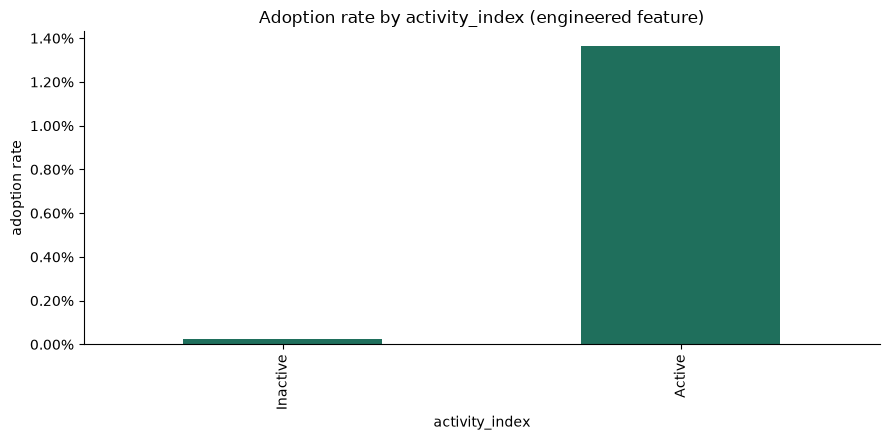

In [4]:
rate_by_activity = adoption_rate_by(train, "activity_index")
rate_by_activity = rate_by_activity.rename(index={0.0: "Inactive", 1.0: "Active"})
print_rate(rate_by_activity, "activity_index (engineered)")
plot_rate_bar(rate_by_activity, "Adoption rate by activity_index (engineered feature)")
plt.show()

### Tenure

Phase 1 EDA (raw column, same bins): **0.11% (<6mo) → 1.44% (20+ yrs)**, ~13x, monotonic.

tenure_months (engineered):
                 rate    count
tenure_bucket                 
(-1, 6]        0.138%   405065
(6, 12]        0.102%   748740
(12, 24]       0.236%  1040189
(24, 36]       0.277%   913316
(36, 60]       0.341%  1108077
(60, 120]      0.822%  1320428
(120, 240]     1.283%  2146355
(240, 1000]    1.859%    12156


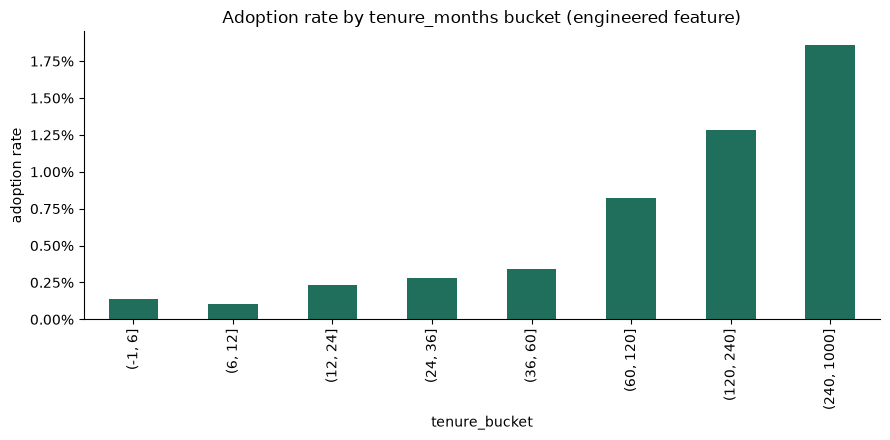

In [5]:
tenure_bins = [-1, 6, 12, 24, 36, 60, 120, 240, 1000]
train["tenure_bucket"] = pd.cut(train["tenure_months"], bins=tenure_bins)

rate_by_tenure = adoption_rate_by(train, "tenure_bucket")
print_rate(rate_by_tenure, "tenure_months (engineered)")
plot_rate_bar(rate_by_tenure, "Adoption rate by tenure_months bucket (engineered feature)")
plt.show()

### Does the imputed 0.16% of rows look different?

If rows that got a fallback (imputed) value adopt at a wildly different rate
than rows with a genuine value, that's a sign missingness itself carries
information — which is exactly why `tenure_missing`/`activity_missing` were
kept as their own columns rather than just filling and moving on.

In [6]:
for col in ["tenure_missing", "activity_missing"]:
    rate = adoption_rate_by(train, col, min_count=50)
    print_rate(rate, col)
    print()

tenure_missing:
                  rate    count
tenure_missing                 
False           0.634%  7674135
True            0.054%    20191



activity_missing:
                    rate    count
activity_missing                 
False             0.634%  7674146
True              0.055%    20180



### Point-biserial correlation with adoption

A quick numeric summary alongside the grouped rates above — the correlation
coefficient between each continuous feature and the binary adoption outcome
(pandas' `.corr()` on a 0/1 column is exactly the point-biserial
correlation). Small in absolute terms is expected and normal here: adoption
is a 0.57%-base-rate rare event, so no single feature will show a large
linear correlation even when it's a strong, useful signal in bucketed/ranked
form (as seen above) — this number is a rough cross-check, not the main
evidence.

In [7]:
corr = train[["tenure_months", "activity_index", "adoption"]].corr()["adoption"].drop("adoption")
print(corr)

tenure_months     0.060002
activity_index    0.084044
Name: adoption, dtype: float64


### Conclusion

Both engineered features reproduce the same direction and rough magnitude of
signal the Phase 1 EDA found on the raw columns — cleaning the `-999999`
tenure placeholder and imputing the small missing share with train-only
statistics didn't wash out the relationship. Group 1 is good to build on;
next up is Group 2 (product count).